# Analphabethismus in kriegsbetroffenen Ländern

## Gruppe: 
Lia Bütikofer (buetilia@students.zhaw.ch), Vanessa Cakoncev (cakonvan@students.zhaw.ch), Lilia Totila (totillil@students.zhaw.ch)

## Fragestellung
Wie hat sich das BIP-Analphabethismus Verhältnis in kriegsbetroffenen Ländern (Afghanistan, Sudan, Syrien und Irak) von 1990 bis 2023 verändert?

## Quellen
https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita


## 1. Daten beschaffen und laden

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# URL zur Our-World-in-Data CSV (Alphabetisierung vs. BIP pro Kopf)
url = "https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita.csv"

# CSV von der URL einlesen
file_name = "literacy-rate-vs-gdp-per-capita.csv"
df = pd.read_csv(file_name)

# ersten Eindruck bekommen
df.head()

,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


## 2. Daten vorbereiten 
- Die Roh-Daten sind bereits im Long-Format
- Für die Analyse werden die Daten pivotiert: Jede Spalte repräsentiert eine Region, die Zeilen sind die verschiedenen Jahre - in absteigender Reihenfolge.

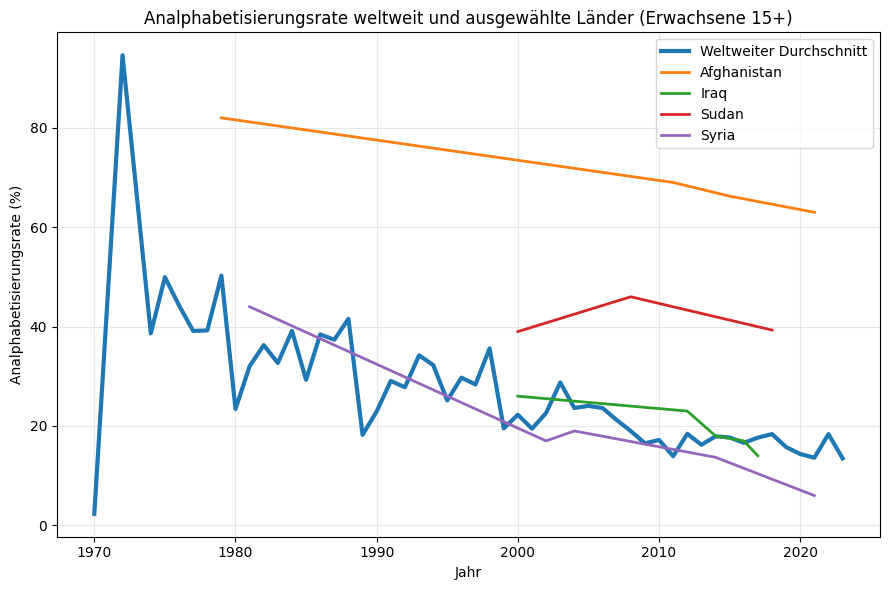

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV-Datei laden
df = pd.read_csv("literacy-rate-adults.csv")

lit_col = "Literacy rate, adult total (% of people ages 15 and above)"
countries = ["Afghanistan", "Iraq", "Sudan", "Syria"]

# Weltweiter Durchschnitt pro Jahr
world = (
    df.groupby("Year")[lit_col]
    .mean()
    .reset_index()
)
world["Illiteracy"] = 100 - world[lit_col]

# Länderlinien vorbereiten
country_lines = {}
for c in countries:
    cdf = df[df["Entity"] == c].copy()
    cdf["Illiteracy"] = 100 - cdf[lit_col]
    country_lines[c] = cdf[["Year", "Illiteracy"]]

# Plot
plt.figure(figsize=(9, 6))

# Weltlinie
plt.plot(
    world["Year"],
    world["Illiteracy"],
    linewidth=3,
    label="Weltweiter Durchschnitt"
)

# Länderlinien
for c, cdf in country_lines.items():
    plt.plot(
        cdf["Year"],
        cdf["Illiteracy"],
        linewidth=2,
        label=c
    )

plt.xlabel("Jahr")
plt.ylabel("Analphabetisierungsrate (%)")
plt.title("Analphabetisierungsrate weltweit und ausgewählte Länder (Erwachsene 15+)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np

def generate_combined_table(file_path):
    """
    Erstellt eine formatierte, pivotierte Tabelle mit BIP und Alphabetisierungsrate 
    für vier spezifische Länder im Zeitraum 1990-2023.
    """
    
    # 1. Parameter definieren
    target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq']
    start_year = 1990
    end_year = 2023
    gdp_column = 'GDP per capita, PPP (constant 2021 international $)'
    literacy_column = 'Literacy rate among adults'

    # 2. Daten laden und filtern
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Fehler: Datei '{file_path}' nicht gefunden.")
        return None

    df_filtered = df[df['Entity'].isin(target_countries)].copy()
    df_filtered['Year'] = pd.to_numeric(df_filtered['Year'], errors='coerce')

    df_plot = df_filtered[
        (df_filtered['Year'] >= start_year) & (df_filtered['Year'] <= end_year)
    ].copy()

    # 3. Spalten auswählen und umbenennen
    df_selected = df_plot[['Entity', 'Year', gdp_column, literacy_column]].copy()
    df_selected.rename(columns={
        'Entity': 'Land',
        'Year': 'Jahr',
        gdp_column: 'BIP ($)',
        literacy_column: 'Rate (%)'
    }, inplace=True)

    # 4. Aggregation (Mittelwert bei Duplikaten pro Land/Jahr)
    df_agg = df_selected.groupby(['Land', 'Jahr']).mean().reset_index()

    # 5. Daten pivotieren und neu ordnen (Jahr, Metrik)
    df_pivot = df_agg.pivot_table(index='Land', columns='Jahr', values=['BIP ($)', 'Rate (%)'])

    # Tausche die Ebenen (Metrik, Jahr) zu (Jahr, Metrik) und sortiere nach Jahr
    df_final = df_pivot.swaplevel(axis=1).sort_index(axis=1)
    df_final.columns.names = ['Jahr', 'Metrik']

    # 6. Formatierung für bessere Lesbarkeit
    def format_value(value, metric):
        if pd.isna(value):
            return '-'
        if metric == 'BIP ($)':
            # Runde auf die nächste Tausender-Zahl und verwende Tausender-Trenner (z.B. 1.234)
            return f"{int(round(value / 1000)):,}".replace(',', '.')
        elif metric == 'Rate (%)':
            # Runde auf eine Dezimalstelle
            return f"{value:.1f}"
        return str(value)

    # Erstelle einen leeren DataFrame für die formatierten Daten
    df_display = pd.DataFrame(index=df_final.index, columns=df_final.columns)

    # Wende die Formatierung auf jede Zelle an
    for (jahr, metric) in df_final.columns:
        df_display[(jahr, metric)] = df_final[(jahr, metric)].apply(lambda x: format_value(x, metric))

    # 7. Speichern der Tabelle (für CSV ist die Standard-MultiIndex-Darstellung am besten)
    output_file_csv = 'BIP_Analphabetisierung_uebersicht_final.csv'
    df_final.to_csv(output_file_csv, index=True)

    print(f"Tabelle gespeichert in: {output_file_csv}")
    print("\n--- Übersichtliche Tabelle ---")
    print(df_display.to_markdown())
    
    return df_display

# Ausführung der Funktion
# Stellen Sie sicher, dass 'literacy-rate-vs-gdp-per-capita.csv' im selben Verzeichnis liegt.
# generate_combined_table('literacy-rate-vs-gdp-per-capita.csv')

In [48]:
df_filtered = df[(df["Year"] >= 1985) & (df["Year"] <= 2025)]
df_filtered.head()

,Entity,Code,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN
5,Afghanistan,AFG,2001,NaN,1454.1108,20284303.0,NaN


## 3. Statistik der Roh-Daten (Analyse im Long-Format)

über die einzelnen Spalten kann folgendes ausgesagt werden:
- Die Spalte *Gebiete* enthält 261 verschieden Gebiete
- Die Spalte *Codes* enthält 239 verschiedene Codes
- Es sind Daten zwischen 1543 and 2021 vorhanden. Ab dem Jahr 1950 sind die Daten komplett
- Die Lebenserwartung streut zwischen 12 und 86.5 Jahren

In [32]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59712 entries, 0 to 59711
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               59712 non-null  object 
 1   Code                                                 55519 non-null  object 
 2   Year                                                 59712 non-null  int64  
 3   Literacy rate among adults                           1725 non-null   float64
 4   GDP per capita, PPP (constant 2021 international $)  7236 non-null   float64
 5   Population (historical)                              58824 non-null  float64
 6   World regions according to OWID                      272 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 3.2+ MB


Index(['Entity', 'Code', 'Year', 'Literacy rate among adults',
       'GDP per capita, PPP (constant 2021 international $)',
       'Population (historical)', 'World regions according to OWID'],
      dtype='object')

### 3.1 Analyse Gebiete

In [49]:
print('Anzahl verschiedener Gebiete: ', len(df['Entity'].unique()))

Anzahl verschiedener Gebiete:  310


In [50]:
# Anzahl Datenpunkte pro Gebiet
df['Entity'].value_counts()

Entity
Zimbabwe                                        262
Zambia                                          262
United Arab Emirates                            262
Ukraine                                         262
Uganda                                          262
                                               ... 
Duchy of Parma and Piacenza                       1
British Indian Ocean Territory                    1
Sudan (former)                                    1
South Georgia and the South Sandwich Islands      1
Austria-Hungary                                   1
Name: count, Length: 310, dtype: int64

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Entity', ylabel='Anzahl Datenpunkte'>

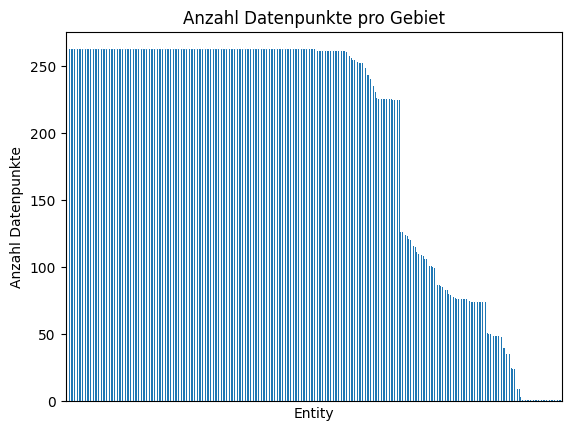

In [35]:
df['Entity'].value_counts().plot(kind='bar', 
                                 xticks=[],     # disable labels on x-axis
                                 ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.2 Analyse Codes

In [36]:
print('Anzahl verschiedener Codes: ', len(df['Code'].unique()))

Anzahl verschiedener Codes:  261


In [37]:
# Anzahl Datenpunkte pro Gebiet
df['Code'].value_counts()

Code
ZWE    262
ZMB    262
GBR    262
ARE    262
UKR    262
      ... 
PCN      1
SGS      1
IOT      1
CCK      1
CXR      1
Name: count, Length: 260, dtype: int64

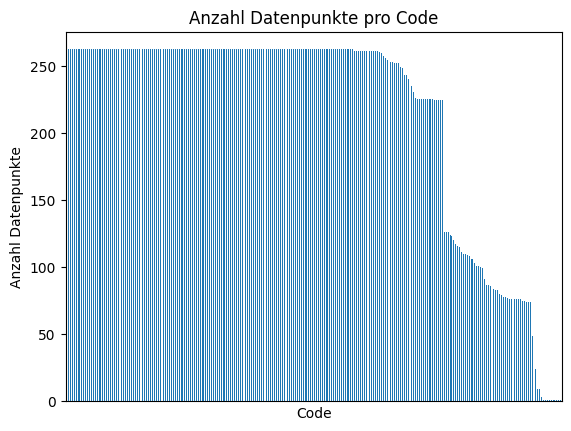

In [38]:
df['Code'].value_counts().plot(kind='bar',xticks=[], ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Code');

### 3.3 Analyse Jahr

### 3.4 Analyse Lebenserwartung

In [39]:
df.describe()

,Year,Literacy rate among adults,"GDP per capita, PPP (constant 2021 international $)",Population (historical)
count,59712.000000,1725.000000,7236.000000,5.882400e+04
mean,1619.756314,77.336331,21729.221482,5.088952e+07
std,1390.459662,19.335627,23785.629715,3.003927e+08
min,-10000.000000,9.000000,510.822800,1.000000e+00
25%,1834.000000,64.492390,4372.770950,1.479938e+05
50%,1904.000000,82.157580,12710.775000,1.409324e+06
75%,1970.000000,94.000000,32508.406000,6.787372e+06
max,2024.000000,100.000000,174339.000000,8.091735e+09


In [40]:
g = df['Lebenserwartung'].plot(kind='hist', bins=20, title='Histogramm der Lebenserwartung', 
                           xlabel='Lebenserwartung', ylabel='Anzahl Datenpunkte')
mean = df['Lebenserwartung'].mean()
g.axvline(x=df['Lebenserwartung'].mean(), color='red',label=f'Mittelwert = {mean:.2f}')  # rote Linie bei Mittelwert

median = df['Lebenserwartung'].median()
g.axvline(x=df['Lebenserwartung'].median(), color='orange',label=  f'Median = {median:.2f}')  # orange Linie bei Median

g.legend()




KeyError: 'Lebenserwartung'

## 4. Analyse 

### Vorgehen

### Beobachtungen
- Afrikanische Länder sind an der Spitze in der Zunahme der Lebenserwartung. Eine Zunahme der Lebenserwartung von mehr als 5 Jahren haben: Uganda, Tanzania, Malawi, Zimbabwe, Lesotho, Swasiland
- Eine Reduktion der Lebenserwartung von mehr als 4 Jahren haben: Saint Vincent and the Grenadines, Mexiko, Kuba, Oman


### Interpretation

Corona führte bei allen Ländern zu einer Reduktion der Lebenserwartung (siehe Plot)

Länder (in Afrika) mit starker Zunahme der Lebensqualität:
- Bei den afrikanischen Ländern stieg die Lebenserwartung in den letzten Jahren sehr stark, da die Lebenserwartung sehr tief war. Zudem ist der Effekt von Corona auf die Lebenserwartung in den afrikanischen Ländern eher kleiner weil die Bevölkerung jünger ist
- Bei einigen afrikanischen Ländern hat sich die Lebenserwartung zwischen 1990 und 2000 stark verringert wegen HIV. Siehe Beispielsweise: https://life4me.plus/pl/news/life-expectancy-in-zimbabwe-shoots-up-hiv-infection-drop/


Länder mit einer starken Reduktion der Lebensqualität:
- Hier war die Lebenserwartung in den Jahren vor Corona konstant. Corona führte dann zu einer Reduktion der Lebenserwartung


### Berechnungen

### Visualisierung

In [ ]:
color_dict = {
    'Saint Vincent and the Grenadines': 'blue',
    'Mexico': 'cyan',
    'Cuba': 'lightgreen',
    'Oman': 'green',
    'Tanzania': 'red',
    'Sierra Leone': 'orange',
    'Malawi': 'yellow',
    'Zimbabwe': 'brown',
    'Lesotho': 'pink',
    'Eswatini': 'purple'
}

for gebiet in Gebiets_liste:
    diff = diffs[gebiet]
    g = df_pivot.loc[gebiet].plot(title='Lebenserwartungen', xlabel='Jahr', ylabel=f'Lebenserwartung', legend=True,
                                  label=f'{gebiet} - Diff. 2021-2011: {diff:.2f}', # für die Legende
                                  xlim=[1980,2025], ylim=[0,80],   # x- und y-Achsen begrenzen
                                  color=color_dict[gebiet],        # Farbe aus color_dict
                                  figsize=(7,7))                   # Grösse des Plots

# Covid Pandemie    
g.axvline(x=2020, color='black', linestyle='--') 
g.text(2020.5, 37, 'Covid')  

# HIV Pandemie
g.axvline(x=2005, color='black', linestyle='--')  
g.text(2005.5, 37, 'HIV');

NameError: name 'Gebiets_liste' is not defined